<a href="https://colab.research.google.com/github/balamurugan-k006/computer-vision-/blob/main/cv%20ex%20Depth%20Map%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving images (1).jpg to images (1) (3).jpg
Saving profilez-le-tir-jeune-du-mâle-roux-élégant-et-sûr-avec-des-taches-de-rousseur-posant-pour-portfolio-l-expression-fraîche-128774460.webp to profilez-le-tir-jeune-du-mâle-roux-élégant-et-sûr-avec-des-taches-de-rousseur-posant-pour-portfolio-l-expression-fraîche-128774460 (2).webp
Resizing right image from (1157, 1600) to match left image's (191, 264)


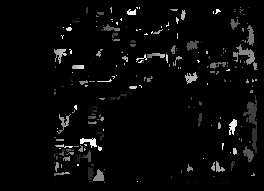

In [6]:
# Install OpenCV (if not already available)
!pip install opencv-python-headless

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload images
uploaded = files.upload()

# Read uploaded images
left_img = cv2.imread('images (1).jpg', cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread('profilez-le-tir-jeune-du-mâle-roux-élégant-et-sûr-avec-des-taches-de-rousseur-posant-pour-portfolio-l-expression-fraîche-128774460.webp', cv2.IMREAD_GRAYSCALE)

# Check if images are loaded
if left_img is None or right_img is None:
    print("Error: Images not loaded. Check file names.")
else:
    # Resize right_img to match left_img dimensions if they are different
    if left_img.shape != right_img.shape:
        print(f"Resizing right image from {right_img.shape} to match left image's {left_img.shape}")
        right_img = cv2.resize(right_img, (left_img.shape[1], left_img.shape[0]))

    # Create Stereo BM matcher
    stereo = cv2.StereoBM_create(numDisparities=16*3, blockSize=15)

    # Compute disparity map
    disparity = stereo.compute(left_img, right_img)

    # Normalize for visualization
    depth_map = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
    depth_map = np.uint8(depth_map)

    # Show result
    cv2_imshow(depth_map)
